In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from collections import defaultdict
import scienceplots

# plt.style.use(['nature'])
# Nature
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 2. Tell the math engine to use custom fonts instead of LaTeX fonts
plt.rcParams['mathtext.fontset'] = 'custom'

# 3. Assign Arial to the standard math modes (for numbers and variables inside $...$)
plt.rcParams['mathtext.rm'] = 'Arial'         # Roman (normal) math text
plt.rcParams['mathtext.it'] = 'Arial:italic'  # Italic math text
plt.rcParams['mathtext.bf'] = 'Arial:bold'    # Bold math text
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  # Do the same if you ever save to .eps

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
# V1064Er = 0.5            # 1064 lattice depth, in 1064 recoil energy
# V532Er = 2.             # 532 lattice depth, in 532 recoil energy
# Rb kHz to Er
# V1064Er = 20. / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0. / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = np.pi/2, 0.
# phi12, phi23 = 0., np.pi/2
# phi12, phi23 = np.pi*1/3, -np.pi*1/3    # decorated triangular lattice (2/3 also works)
# phi12, phi23 = np.pi*4e-3, -np.pi*4e-3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 6             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 4         # inclusive
# qverts_str = 'np.array([0.4, -0.4]), np.array([0.4, 0.4]), np.array([-0.4, 0.4]), np.array([-0.4, -0.4]), np.array([0.4, -0.4])'
# qverts_str = 'E9c.Kp4/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'
# x_ticklist = ["K'", '$\Gamma$', 'K', 'M', '$\Gamma$']
qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$']
save_results = False

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

In [5]:
def MinimumGap(e_values, band1, band2):
    """Prints the position and energy of the minimum gap.
    
    Example: MinimumGap(e_values,2,3)
    Should be slightly enhanced to return something
    """
    gaps = e_values[:, band2] - e_values[:, band1]
    print('The minimum band gap between band{} and band{} is {} kHz, happening at the {} (python index) q evaluated' \
          .format(band1, band2, gaps.min() * f_unit / 1e3 / (2 * np.pi), gaps.argmin()))

# Real space plots

Pretty sure that the orientation is still wrong - maybe flipped about $x = 0$?

In [6]:
bool_plot_real = True
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6

C:\Users\ken92\AppData\Local\Temp\ipykernel_37896\1398260329.py:17: RuntimeWarning: invalid value encountered in divide
  alpha = V_real / np.nanmax(V_real)


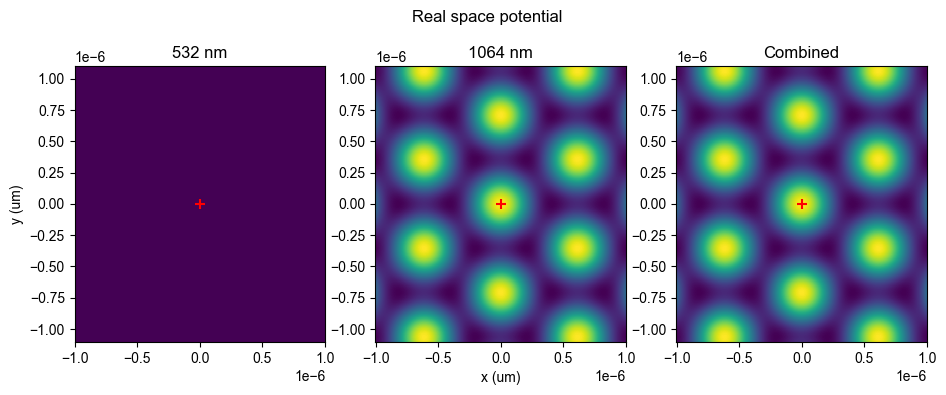

In [7]:
pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real
fig_real = plt.figure(figsize = (11, 4))
ax_532 = fig_real.add_subplot(131, aspect = "equal")
ax_1064 = fig_real.add_subplot(132, aspect = "equal")
ax_super = fig_real.add_subplot(133, aspect = "equal")
fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")
if bool_plot_real:
    for ax, V_real, ax_title in zip([ax_532, ax_1064, ax_super],
                                    [V_532_real, V_1064_real, V_super_real],
                                    ["532 nm", "1064 nm", "Combined"],):
        alpha = V_real / np.nanmax(V_real)
        im = ax.pcolormesh(x_real, y_real, V_real, cmap = 'viridis')
        ax.scatter(0, 0, color = 'red', marker = '+', s = 50)
        ax.set_title(ax_title)
        # fig_real.colorbar(im, ax = ax)
    

# Finding Bloch states and band energies

In [8]:
rq_circ = 0.65625
dq = 0.65625 * 2 * np.pi / 360

In [9]:
start_time = time.time()

# Generate qset
num_points = int(2. * np.pi * rq_circ / dq)
qsets, xq = bsc.find_qset_circle(E9c.Gp/E9c.k_lw, rq_circ, theta_init = np.pi + 0.001, pt_num = num_points)

e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

# find non-interacting solution
print("Total number of points = {0}".format(len(qsets)))
Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)

# Fix the gauge of eigenstates using parallel transport
e_states_fixed = bsc.fix_gauge_parallel_transport_1d(e_states, flip_gauge_for_bands = [0])
for i in range(len(qsets)):
    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
print("--- {0} seconds ---".format((time.time() - start_time)))


Total number of points = 360
--- 1.7681808471679688 seconds ---


## Fig. 2a
Added so many things that this deserves its own block.

In [10]:
str_journal = "BIGGUS"  # for screen display
str_journal = "nature"

mm2inch = 1 / 25.4
plt_sizes_all_journals = {
    "nature": {
        "fig_BZ_figsize":       np.array([25, 30]) * mm2inch,

        "BZ_lw":                0.5,
        "BZ_q_pt_s_scat":       0.6,
        "sym_pt_fontsize":      7,
        "q_circ_lw":            1,
        "q_circ_arrowstyle":    '-|>,head_width=0.02,head_length=0.05',

        "theta_PM_--lw":        0.7,
        "theta_PM_arclw":       0.6,
        "theta_PM_fontsize":    7,
        "PM_arrow_stem_lw":     1.,
        "PM_arrow_arrowstyle":  '<|-|>,head_width=0.03,head_length=0.04',

        "coor_arrow_lw":        0.5,
        "coor_arrowstyle":      '-|>,head_width=0.01,head_length=0.02',
        "coor_fontsize":        6,

        # Berry connection plot
        "fig_Berry_figsize":    np.array([30, 30]) * mm2inch,

        "A12_circ_lw":          1,
        "A12_circ_arrowstyle":  '-|>,head_width=0.03,head_length=0.1',
        "quiver_lw":            0.3,
        "A12_text_fontsize":    7,
        "r_circ_scale":         0.8,
    },
    "BIGGUS": {
        "fig_BZ_figsize":       np.array([5, 4.5]),

        "BZ_lw":                2,
        "BZ_q_pt_s_scat":       64,
        "sym_pt_fontsize":      30,
        "q_circ_lw":            3,
        "q_circ_arrowstyle":    '-|>,head_width=0.08,head_length=0.16',

        "theta_PM_--lw":        2.5,
        "theta_PM_arclw":       1.8,
        "theta_PM_fontsize":    32,
        "PM_arrow_stem_lw":     4,
        "PM_arrow_arrowstyle":  '<|-|>,head_width=0.14,head_length=0.26',

        "coor_arrow_lw":        3,
        "coor_arrowstyle":      '-|>,head_width=0.05,head_length=0.12',
        "coor_fontsize":        30,

        # Berry connection plot
        "fig_Berry_figsize":    np.array([5, 5]),

        "A12_circ_lw":          5,
        "A12_circ_arrowstyle":  '-|>,head_width=0.2,head_length=0.55',
        "quiver_lw":            1.5,
        "A12_text_fontsize":    50,
        "r_circ_scale":         1.,
    }
}

plt_sizes = plt_sizes_all_journals[str_journal]

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'Gamma', 'K', 'M', 'glyph00001', 'glyph00002', 'quotesingle', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 10, 46, 48, 299]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', 'Gamma', 'K', 'M', 'glyph00001', 'glyph00002', 'quotesingle', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 10, 46, 48, 299]
INFO:fontTools.sub

For nature submission


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 7 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'glyph00001', 'glyph00002', 'q', 'space', 'x', 'y']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 84, 91, 92]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 7 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', 'glyph00001', 'glyph00002', 'q', 'space', 'x', 'y']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 84, 91, 92]
INFO:fontTools.subset:Closing glyph list over 'glyf': 7 glyphs before
INFO:fontTools.subset:Glyph nam

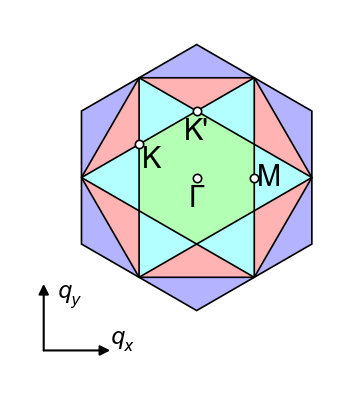

In [13]:
# BZ plot
print(f"For {str_journal} submission")

fig_BZ, ax_BZ = plt.subplots(1, 1, figsize = plt_sizes["fig_BZ_figsize"], dpi = 300)

# orientation (arrows only show up if there are ax.plot() after)
coor_pos = np.array([-2.3, -2.6])
x_axis_tip = np.array([1, 0]) + coor_pos
y_axis_tip = np.array([0, 1]) + coor_pos
for p1 in (x_axis_tip, y_axis_tip):
    arrow = FancyArrowPatch(
        coor_pos, p1,
        edgecolor = "black",
        facecolor = "black",
        linewidth = plt_sizes["coor_arrow_lw"],
        arrowstyle = plt_sizes["coor_arrowstyle"],
        mutation_scale = 100,
        shrinkA = 0,
        shrinkB = 0
    )
    ax_BZ.add_patch(arrow)
ax_BZ.text(*x_axis_tip + np.array([0., 0.1]), r"$q_x$", fontsize = plt_sizes["coor_fontsize"])
ax_BZ.text(*y_axis_tip + np.array([0.2, -0.2]), r"$q_y$", fontsize = plt_sizes["coor_fontsize"])

bsc.PlotBZSubplot(ax_BZ, N_BZ = 4, BZ_kwargs = {"lw": 0.4},
                  add_q_pts = False, s_q_pt = plt_sizes["BZ_q_pt_s_scat"],
                  label_sym_pts = True, sym_pt_kwargs = {"facecolor": "white", "edgecolor": "black", "linewidth": 0.4, "s": 4}, fontsize = plt_sizes["sym_pt_fontsize"])
ax_BZ.axis("off")

fig_BZ.tight_layout(pad = 0)

# Add definition of \theta_{PM}
if 0:
    color_theta_PM = "#444444"
    hline_endpt = rq_circ * E9c.Mp4 / E9c.k_lw
    theta_PM_example = np.pi * 8.5 / 10
    theta_endpt = rq_circ * np.array([np.cos(theta_PM_example), np.sin(theta_PM_example)])
    theta_arrow_endpt = 0.7 * theta_endpt
    theta_stem_endpt = 0.45 * theta_endpt

    ax_BZ.plot([0, hline_endpt[0]], [0, hline_endpt[1]],
            color = color_theta_PM, linestyle = "--", linewidth = plt_sizes["theta_PM_--lw"])
    ax_BZ.plot([0, theta_endpt[0]], [0, theta_endpt[1]],
            color = color_theta_PM, linestyle = "--", linewidth = plt_sizes["theta_PM_--lw"])
    util.draw_circle(ax_BZ, center = (0, 0), radius = 0.2, theta_range = (0, theta_PM_example),
                    close_circle = False, color = color_theta_PM, linestyle = "-", linewidth = plt_sizes["theta_PM_arclw"])
    ax_BZ.text(0., 0.25, r"$\theta_{\mathrm{PM}}$", color = color_theta_PM, fontsize = plt_sizes["theta_PM_fontsize"])
    ax_BZ.plot([- theta_stem_endpt[0], theta_stem_endpt[0]], [- theta_stem_endpt[1], theta_stem_endpt[1]],
            color = color_theta_PM, linestyle = "-", linewidth = plt_sizes["PM_arrow_stem_lw"])
    arrow_PM = FancyArrowPatch(
                    theta_arrow_endpt,
                    -theta_arrow_endpt,
                    edgecolor = "none",         # This smoothes out the arrow
                    facecolor = color_theta_PM,
                    arrowstyle = plt_sizes["PM_arrow_arrowstyle"],
                    mutation_scale = 50,
                    shrinkA = 0,
                    shrinkB = 0
                )
    ax_BZ.add_patch(arrow_PM)

# Save
fig1bpath = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig1",
                 f"fig1b_{str_journal}.pdf")
fig_BZ.savefig(fig1bpath, format = "pdf", facecolor = "none", dpi = 300)#, bbox_inches = 'tight')